C:\Users\chand\anaconda3\New folder\New folder\python\lib\site-packages\google\api_core\_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.9) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
C:\Users\chand\anaconda3\New folder\New folder\python\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Starting YouTube data collection...
Searching for channels: tech startup
Found 10 channels
Searching for channels: kickstarter campaign
Found 10 channels
Searching for channels: crowdfunding project
Found 10 channels
Searching for channels: startup pitch
Found 10 channels
Searching for channels: product launch
Found 10 channels
Searching for channels: indie game developer
Found 10 channels
Searching for channels: hardware startup
Found 10 channels
Searching for channels: app development
Found 25 channels
Collected data for 95 channels
Saved YouTube data to C:/Users/chand/OneDrive/Desktop/7th sem/startup-prediction/data/raw/youtube_channels.csv
Loading YouTube dataset...
Loaded 95 records

Handling missing values...

Extracting datetime features...

Calculating engagement metrics...
Created engagement metrics

Categorizing channel sizes...

Removing outliers...
Removed 0 outlier records

Saving processed YouTube data to C:/Users/chand/OneDrive/Desktop/7th sem/startup-prediction/data/pro

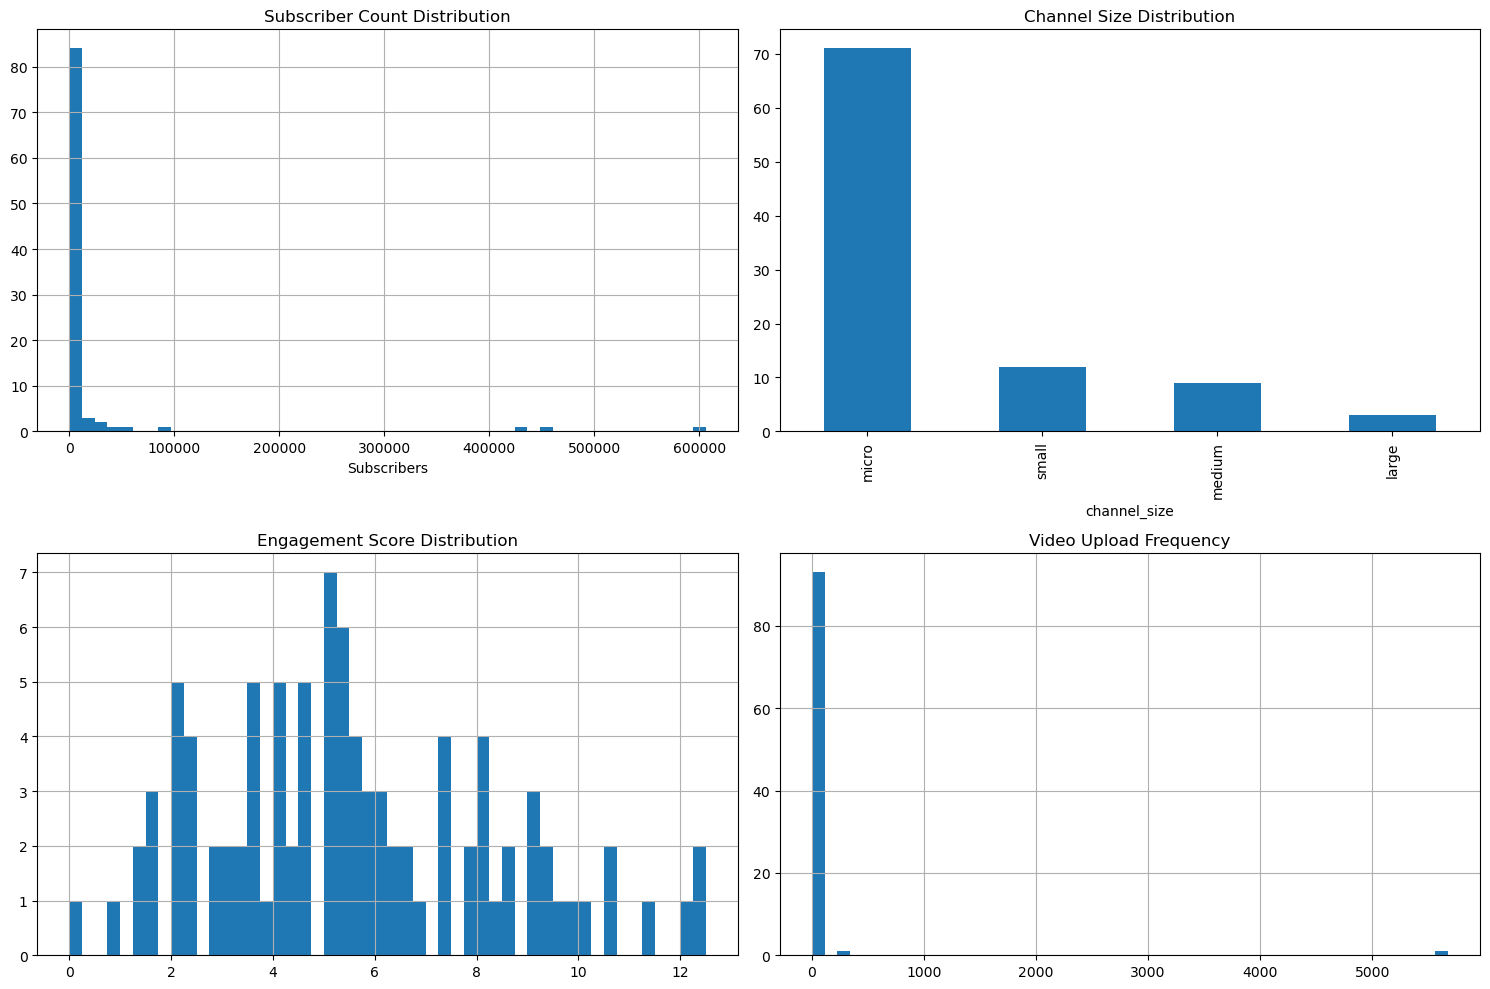

In [1]:
import sys
sys.path.append('../src')

from data_collection.youtube_collector import YouTubeDataCollector
from preprocessing.youtube_preprocessor import YouTubePreprocessor

# Step 1: Collect data
collector = YouTubeDataCollector()

startup_queries = [
    "tech startup",
    "kickstarter campaign",
    "crowdfunding project",
    "startup pitch",
    "product launch",
    "indie game developer",
    "hardware startup",
    "app development"
]

df_raw = collector.collect_startup_channels_data(startup_queries, max_channels_per_query=10)
collector.save_data(df_raw, 'C:/Users/chand/OneDrive/Desktop/7th sem/startup-prediction/data/raw/youtube_channels.csv')

# Step 2: Preprocess
preprocessor = YouTubePreprocessor('C:/Users/chand/OneDrive/Desktop/7th sem/startup-prediction/data/raw/youtube_channels.csv')
df_processed = preprocessor.run_full_pipeline('C:/Users/chand/OneDrive/Desktop/7th sem/startup-prediction/data/processed/youtube_processed.csv')

# Visualizations
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Subscriber distribution
df_processed['subscriber_count'].hist(bins=50, ax=axes[0,0])
axes[0,0].set_title('Subscriber Count Distribution')
axes[0,0].set_xlabel('Subscribers')

# Channel size distribution
df_processed['channel_size'].value_counts().plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title('Channel Size Distribution')

# Engagement score
df_processed['engagement_score'].hist(bins=50, ax=axes[1,0])
axes[1,0].set_title('Engagement Score Distribution')

# Videos per year
df_processed['videos_per_year'].hist(bins=50, ax=axes[1,1])
axes[1,1].set_title('Video Upload Frequency')

plt.tight_layout()
plt.savefig('C:/Users/chand/OneDrive/Desktop/7th sem/startup-prediction/data/youtube_eda.png')
plt.show()
